# 삼중차분(DDD) 본분석과 세그먼트별 용량반응 분석 — 인천e음 정책 패키지

**질문** 2026년 5~6월 인천의 BC카드 식음료 소비 감소가 캐시백 대상 업종에서만 나타나는가(DDD), 그리고 e음 자격이 다른 세그먼트(내국인·외국인·법인)에서 감소 크기가 자격 순서와 맞는가(용량반응). 위약검정 대상은 e음을 쓸 수 없는 **법인** 하나다.

**규약** `CLAUDE.md` 계산 규약을 따른다. PRE = 1~4월, POST = 5~6월, **월평균** 비교, 전국은 인천 제외(leave-one-out), C = 대형할인점(캐시백 비대상), T = 나머지 10개 업종. **이천시**(5월 전체 가맹점 캐시백)는 확정 배제이므로 로드 단계에서 제거한다. 부산·경남은 대조군 변형으로 따로 다룬다.

**구성**
1. 수동 DDD — 대조군 3종 + 한정식·갈비전문점 제외 민감도
2. 회귀 DDD — 시군구×업종 FE + 월×업종 FE, 시군구 클러스터 SE
3. 이벤트 스터디 — 월별 계수로 사전 추세와 5→6월 확대 확인
4. 세그먼트별 용량반응 분석(내국인·외국인·법인) — 안정성 → DiD·DDD → 시군구 분포에서의 위치. 법인만 위약검정

## 0. 환경 설정

In [1]:
import pandas as pd, numpy as np, statsmodels.api as sm, warnings
import matplotlib.pyplot as plt, matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Apple SD Gothic Neo'
mpl.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('ABP_CONTEST_DATA.csv')
df['GENDER_CD'] = df.GENDER_CD.astype(str)
PRE  = [202601, 202602, 202603, 202604]
POST = [202605, 202606]
df['grp']     = np.where(df.TP_BUZ_NM == '대형할인점', 'C', 'T')
df['post']    = df.STRD_YYMM.isin(POST).astype(int)
df['incheon'] = (df.SIDO_NM == '인천광역시').astype(int)
df['region']  = df.SIDO_NM + ' ' + df.CCG_NM
n0 = len(df)
df = df[~((df.SIDO_NM == '경기도') & (df.CCG_NM == '이천시'))].copy()   # 확정 배제 대조군
print(df.shape, '| 이천시 제거', n0 - len(df), '행 | 인천 행수', df.incheon.sum())

(241540, 13) | 이천시 제거 1034 행 | 인천 행수 9623


## 1. 수동 DDD
증감률 = POST 월평균 / PRE 월평균 − 1. DiD(T) = 인천 T − 대조군 T, DiD(C) = 인천 C − 대조군 C, **DSI = DiD(T) − DiD(C)**.

In [2]:
def rate(d):
    return (d[d.post == 1].amt.sum() / 2) / (d[d.post == 0].amt.sum() / 4) * 100 - 100

def ddd(reg, ctrl):
    T = lambda d: d[d.grp == 'T']; C = lambda d: d[d.grp == 'C']
    r = dict(인천T=rate(T(reg)), 대조T=rate(T(ctrl)), 인천C=rate(C(reg)), 대조C=rate(C(ctrl)))
    r['DiD_T'] = r['인천T'] - r['대조T']; r['DiD_C'] = r['인천C'] - r['대조C']; r['DSI'] = r['DiD_T'] - r['DiD_C']
    return r

def controls(d):
    rest = d[d.incheon == 0]
    return {'전국 전체': rest,
            '부산·경남 제외': rest[~rest.SIDO_NM.isin(['부산광역시', '경상남도'])],
            '수도권만': rest[rest.SIDO_NM.isin(['서울특별시', '경기도'])]}

inc = df[df.incheon == 1]
manual = pd.DataFrame({k: ddd(inc, v) for k, v in controls(df).items()}).T
manual

,인천T,대조T,인천C,대조C,DiD_T,DiD_C,DSI
전국 전체,-1.39,10.69,-8.79,-6.99,-12.08,-1.80,-10.28
부산·경남 제외,-1.39,8.56,-8.79,-7.51,-9.95,-1.28,-8.67
수도권만,-1.39,6.01,-8.79,-7.35,-7.40,-1.44,-5.96


In [3]:
ex = df[~df.TP_BUZ_NM.isin(['한정식', '갈비전문점'])]
sens = pd.DataFrame({k: ddd(ex[ex.incheon == 1], v) for k, v in controls(ex).items()}).T[['DiD_T', 'DiD_C', 'DSI']]
sens.columns = ['DiD_T(제외)', 'DiD_C(제외)', 'DSI(제외)']
pd.concat([manual[['DSI']], sens], axis=1)

,DSI,DiD_T(제외),DiD_C(제외),DSI(제외)
전국 전체,-10.28,-12.07,-1.80,-10.27
부산·경남 제외,-8.67,-9.95,-1.28,-8.67
수도권만,-5.96,-7.40,-1.44,-5.96


- 전국 전체 대조군 DSI **−10.3%p**, 부산·경남 제외 −8.7, 수도권 −6.0. 이천시 제거 전 `CLAUDE.md` 잠정치(−10.2 / −8.6 / −5.9)에서 0.05pt 안팎 이동.
- 대형할인점은 인천도 대조군도 5~6월에 −7~−9% 빠졌다(전국 공통 계절·정책 요인). 인천만의 추가 감소는 T 업종에서만 난다.
- 한정식·갈비전문점을 빼도 DSI는 소수점 둘째 자리에서만 움직인다(−10.28 → −10.27). 문서의 "약 −9.1"은 재현되지 않는다 → 제외 여부는 결과에 영향 없으므로 **포함**으로 통일해도 무방.

## 2. 회귀 DDD
셀 = 시군구 × 업종 × 월(성별·연령 합산), 종속변수 log(amt).

```
log(Y) = β₄(Post×인천) + β₇(Post×인천×대상) + 시군구×업종 FE + 월×업종 FE + ε
```
고정효과는 더미 대신 **반복 평균제거(alternating projection)** 로 흡수한다. 더미 수천 개를 그대로 넣으면 클러스터 공분산이 특이해져 SE가 나오지 않는다. SE는 시군구 클러스터.

In [4]:
def cells(d):
    c = d.groupby(['region', 'SIDO_NM', 'TP_BUZ_NM', 'STRD_YYMM', 'incheon', 'post', 'grp'], as_index=False).amt.sum()
    c['treat'] = (c.grp == 'T').astype(int)
    c['y']  = np.log(c.amt)
    c['pi'] = c.post * c.incheon           # β4: Post × 인천
    c['pit'] = c.pi * c.treat              # β7: Post × 인천 × 대상
    c['ri'] = c.region + '|' + c.TP_BUZ_NM             # 시군구×업종 FE
    c['mi'] = c.STRD_YYMM.astype(str) + '|' + c.TP_BUZ_NM   # 월×업종 FE
    for m in [202601, 202602, 202603, 202605, 202606]:   # 이벤트 스터디용 (기준 = 4월)
        c[f'i{m}']  = ((c.STRD_YYMM == m) * c.incheon).astype(int)
        c[f'it{m}'] = c[f'i{m}'] * c.treat
    return c

def demean2(X, f1, f2, tol=1e-9, maxit=500):
    X = X.copy()
    for _ in range(maxit):
        X0 = X.copy()
        X = X - X.groupby(f1).transform('mean')
        X = X - X.groupby(f2).transform('mean')
        if (X - X0).abs().max().max() < tol:
            break
    return X

def fe_reg(c, xs, cluster='region'):
    Y = demean2(c[['y'] + xs], c.ri, c.mi)
    m = sm.OLS(Y.y, Y[xs]).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(c[cluster])[0]})
    out = pd.DataFrame({'coef': m.params, 'se': m.bse, 'p': m.pvalues, '효과(%)': (np.exp(m.params) - 1) * 100})
    out.attrs['n'] = len(c)
    return out

samples = {'전국 전체': df,
           '부산·경남 제외': df[~df.SIDO_NM.isin(['부산광역시', '경상남도'])],
           '수도권만': df[df.SIDO_NM.isin(['서울특별시', '경기도', '인천광역시'])]}
rows = []
for k, d in samples.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_tbl = pd.concat(rows).set_index(['대조군', '계수'])
reg_tbl

coef   se    p  효과(%)     n셀
대조군      계수                                                 
전국 전체    β4 post:incheon        0.02 0.04 0.57   2.06  14064
         β7 post:incheon:treat -0.14 0.06 0.03 -13.10  14064
부산·경남 제외 β4 post:incheon        0.02 0.04 0.62   1.78  11807
         β7 post:incheon:treat -0.12 0.06 0.05 -11.49  11807
수도권만     β4 post:incheon        0.02 0.04 0.53   2.37   4544
         β7 post:incheon:treat -0.09 0.06 0.17  -8.32   4544

- 전국 대조군: **β₄ +2.1% (p 0.57)** — 대형할인점에서는 인천만의 변화가 없다(업종 위약검정 통과). **β₇ −13.1% (p 0.03)** — 캐시백 대상 업종에서만 추가 감소.
- 대조군을 좁힐수록 β₇는 −11.5 → −8.3%로 줄고 p는 0.05 → 0.17로 커진다. 수도권만 쓰면 시군구 클러스터가 70개 안팎이라 검정력이 낮다. 방향과 크기(수동 DSI −5.9~−10.2)는 유지.
- 수동(−10.3)과 회귀(−13.1)의 차이는 가중 방식(금액 가중 vs 셀 균등)이다. 본문은 수동, 회귀는 부록.

## 3. 이벤트 스터디
4월을 기준(0)으로 월별 인천 계수를 본다. `it` 계수가 대상 업종의 추가 효과. 1~3월이 0 근처면 사전 추세가 평행하다.

In [5]:
months = [202601, 202602, 202603, 202605, 202606]
ev = fe_reg(cells(df), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t = ev.loc[[f'it{m}' for m in months]].copy(); ev_t.index = [f'{m % 100}월' for m in months]
ev_c = ev.loc[[f'i{m}' for m in months]].copy();  ev_c.index = ev_t.index
pd.concat({'대상 업종 추가효과(it)': ev_t, '대형할인점(i)': ev_c}, axis=1)

대상 업종 추가효과(it)                  대형할인점(i)                
             coef   se    p  효과(%)     coef   se    p 효과(%)
1월           0.05 0.04 0.23   5.32    -0.05 0.05 0.32 -4.99
2월           0.04 0.05 0.37   4.11    -0.06 0.06 0.31 -5.55
3월           0.07 0.04 0.07   7.01    -0.05 0.05 0.34 -4.43
5월          -0.09 0.07 0.16  -9.04    -0.02 0.04 0.60 -1.99
6월          -0.11 0.07 0.14 -10.04    -0.02 0.05 0.76 -1.58

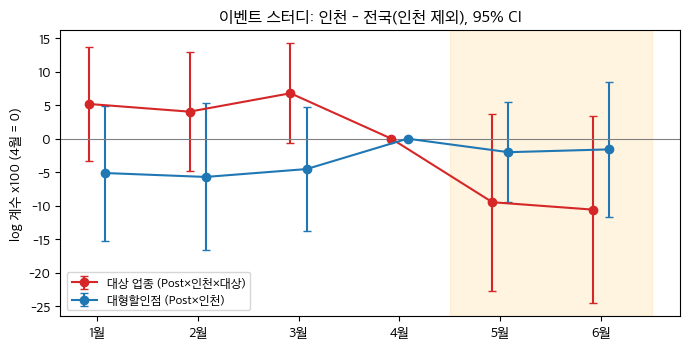

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(len(months) + 1); labels = ['1월', '2월', '3월', '4월', '5월', '6월']
for name, tbl, col, off in [('대상 업종 (Post×인천×대상)', ev_t, 'C3', -0.08), ('대형할인점 (Post×인천)', ev_c, 'C0', 0.08)]:
    coef = np.insert(tbl.coef.values, 3, 0) * 100; se = np.insert(tbl.se.values, 3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt='o-', color=col, capsize=3, label=name)
ax.axhline(0, color='grey', lw=0.8); ax.axvspan(3.5, 5.5, color='orange', alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('log 계수 x100 (4월 = 0)')
ax.set_title('이벤트 스터디: 인천 - 전국(인천 제외), 95% CI'); ax.legend(fontsize=9, loc='lower left')
plt.tight_layout(); plt.show()

- **1~3월 대상 업종 계수 +4~+7%** — 4월 기준으로 보면 1~3월이 살짝 높다. 즉 4월이 이미 조금 낮았다(4/14 캐시백 확대 발표 후 소비 이연 가능성). 1~3월 세 값은 서로 ±1.5pt 안에 있어 추세 자체는 평행하다.
- **5월 −9.0%, 6월 −10.0%** — 시행과 동시에 꺾이고 6월에 더 커진다. 대형할인점 계수는 전 기간 −2~−6%로 평탄하고 0과 구분되지 않는다.
- 월별 계수는 개별로는 p 0.14~0.16(클러스터 SE가 큼). 방향과 시점 일치가 근거이고, 유의성은 2절의 합산 계수(β₇)가 담당한다.

## 4. 세그먼트별 용량반응 분석 — 내국인 · 외국인 · 법인
인천e음 가입 자격이 세그먼트마다 다르다. **내국인**(`GENDER_CD` 1·2)은 전면 대상, **외국인**(3)은 외국인등록증으로 가입 가능하나 이용률이 낮을 것으로 예상, **법인**(x)은 사용 불가.
대체효과라면 감소 크기가 **내국인 > 외국인 > 법인 ≈ 0** 순서여야 한다(용량반응). 이 중 효과가 0이어야 하는 집단은 법인뿐이므로 **위약검정은 법인 하나**다. 외국인은 e음을 쓸 수 있어 효과가 작을 뿐 0일 필요가 없다. 세 세그먼트를 같은 규약(DiD·DDD·회귀·시군구 순위)으로 나란히 본다.

### 4-0. 규모와 안정성

In [7]:
segs = {'내국인': df[df.GENDER_CD.isin(['1', '2'])], '외국인': df[df.GENDER_CD == '3'], '법인': df[df.GENDER_CD == 'x']}
rows = []
for k, s in segs.items():
    sido = s.groupby('SIDO_NM').apply(rate, include_groups=False)
    rows.append({'세그먼트': k, '행수': len(s), '금액 비중(%)': s.amt.sum() / df.amt.sum() * 100, '인천 행수': int(s.incheon.sum()),
                 '인천 증감률(%)': rate(s[s.incheon == 1]), '전국(인천 제외) 증감률(%)': rate(s[s.incheon == 0]),
                 '시도 증감률 최소(%)': sido.min(), '시도 중앙값(%)': sido.median(), '시도 최대(%)': sido.max(),
                 '인천 시도 순위(낮은 순)': int(sido.rank()['인천광역시'])})
pd.DataFrame(rows).set_index('세그먼트')

,행수,금액 비중(%),인천 행수,인천 증감률(%),전국(인천 제외) 증감률(%),시도 증감률 최소(%),시도 중앙값(%),시도 최대(%),인천 시도 순위(낮은 순)
세그먼트,,,,,,,,,
내국인,158573,86.45,6317,-2.80,5.05,-2.80,6.21,12.20,1
외국인,69860,7.41,2798,1.60,8.22,1.60,8.57,16.00,1
법인,13107,6.15,508,9.11,74.53,6.56,26.38,592.56,3


In [8]:
pd.DataFrame({k: s.groupby('SIDO_NM').apply(rate, include_groups=False) for k, s in segs.items()}).sort_values('내국인').T

SIDO_NM,인천광역시,서울특별시,광주광역시,경상남도,울산광역시,제주특별자치도,경기도,부산광역시,전라남도,경상북도,전북특별자치도,충청북도,세종특별자치시,대전광역시,대구광역시,충청남도,강원특별자치도
내국인,-2.80,1.75,2.15,2.44,3.05,3.75,5.16,5.30,6.21,7.40,7.70,7.75,7.94,8.05,8.24,9.25,12.20
외국인,1.60,4.88,6.13,8.07,7.44,8.57,7.11,9.99,6.69,12.85,9.83,10.01,8.58,6.85,9.97,11.53,16.00
법인,9.11,19.09,68.72,592.56,208.66,109.87,22.46,301.42,206.75,13.67,34.25,11.57,6.56,17.08,8.88,26.38,31.56


- 내국인이 금액의 86%, 외국인 7%, 법인 6%. 인천 행수는 각각 6,317 / 2,798 / 508로 셋 다 회귀에 충분하다.
- **절대 수준**: 내국인 −2.8%(17개 시도 중 유일한 마이너스), 외국인 +1.6%(최하위이나 플러스), 법인 +9.1%(하위 3위).
- 대조군 안정성은 세그먼트마다 다르다. 내국인·외국인 시도 증감률은 −3~+16% 범위로 좁다. **법인은 +7~+593%**로 분산이 극단적(경남·부산·울산·전남 급증) → 법인의 금액 가중 DiD는 대조군 선택에 크게 흔들린다.
- 외국인 행수(70,178)가 남성(80,554)에 맞먹는 것은 "외국인" 코드 정의가 의심스럽다. 주최측 문의 항목.

### 4-1. 수동 DiD·DDD — 세그먼트 × 대조군

In [9]:
rows = []
for k, s in segs.items():
    for name, ctl in controls(s).items():
        r = ddd(s[s.incheon == 1], ctl)
        rows.append({'세그먼트': k, '대조군': name, **{a: r[a] for a in ['인천T', '대조T', 'DiD_T', 'DiD_C', 'DSI']}})
manual_seg = pd.DataFrame(rows).set_index(['세그먼트', '대조군'])
manual_seg

인천T   대조T  DiD_T  DiD_C    DSI
세그먼트 대조군                                      
내국인  전국 전체    -2.17  6.50  -8.67  -1.56  -7.11
     부산·경남 제외 -2.17  6.65  -8.82  -0.98  -7.84
     수도권만     -2.17  5.15  -7.31  -1.17  -6.14
외국인  전국 전체     2.88  9.62  -6.74  -4.32  -2.42
     부산·경남 제외  2.88  9.44  -6.56  -3.87  -2.69
     수도권만      2.88  7.99  -5.10  -3.60  -1.50
법인   전국 전체    10.35 79.03 -68.68  -3.11 -65.57
     부산·경남 제외 10.35 35.98 -25.64  -3.44 -22.20
     수도권만     10.35 23.28 -12.93  -2.57 -10.36

### 4-2. 회귀 DDD — 세그먼트 × 대조군
셀 균등 가중이라 법인 대조군의 금액 급증에 덜 휘둘린다.

In [10]:
rows = []
for k, s in segs.items():
    for name, sub in {'전국 전체': s, '부산·경남 제외': s[~s.SIDO_NM.isin(['부산광역시', '경상남도'])],
                      '수도권만': s[s.SIDO_NM.isin(['서울특별시', '경기도', '인천광역시'])]}.items():
        r = fe_reg(cells(sub), ['pi', 'pit'])
        rows.append({'세그먼트': k, '대조군': name, 'n셀': r.attrs['n'],
                     'β4 대형할인점(%)': r.loc['pi', '효과(%)'], 'β4 p': r.loc['pi', 'p'],
                     'β7 대상업종(%)': r.loc['pit', '효과(%)'], 'β7 p': r.loc['pit', 'p']})
reg_seg = pd.DataFrame(rows).set_index(['세그먼트', '대조군'])
reg_seg

n셀  β4 대형할인점(%)  β4 p  β7 대상업종(%)  β7 p
세그먼트 대조군                                                 
내국인  전국 전체     14054         2.57  0.48      -10.65  0.08
     부산·경남 제외  11797         2.34  0.53      -11.05  0.07
     수도권만       4544         2.71  0.48       -8.39  0.17
외국인  전국 전체     12946        -1.83  0.68       -5.22  0.35
     부산·경남 제외  10970        -2.08  0.65       -5.14  0.37
     수도권만       4320         0.10  0.98       -3.25  0.57
법인   전국 전체     13107        -1.05  0.71      -32.46  0.00
     부산·경남 제외  11028        -1.64  0.58      -15.67  0.00
     수도권만       4329        -0.96  0.76      -10.52  0.00

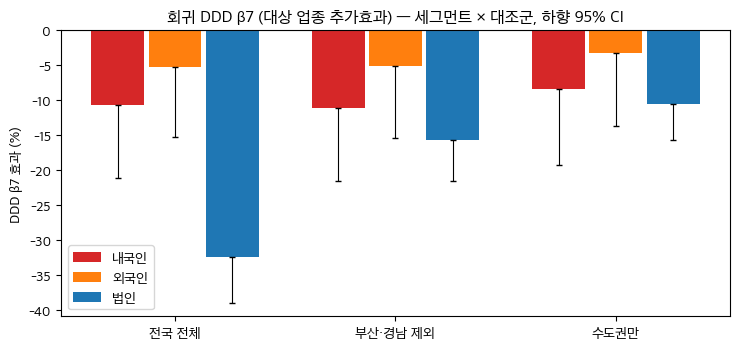

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ctl_names = ['전국 전체', '부산·경남 제외', '수도권만']; x = np.arange(len(ctl_names))
for j, (k, col) in enumerate(zip(segs, ['C3', 'C1', 'C0'])):
    sub = reg_seg.loc[k].reindex(ctl_names)
    b = sub['β7 대상업종(%)'].values
    lo = (np.exp(np.log1p(b / 100) - 1.96 * np.array([fe_reg(cells(d), ['pi', 'pit']).loc['pit', 'se'] for d in
          [segs[k], segs[k][~segs[k].SIDO_NM.isin(['부산광역시', '경상남도'])], segs[k][segs[k].SIDO_NM.isin(['서울특별시', '경기도', '인천광역시'])]]])) - 1) * 100
    ax.bar(x + (j - 1) * 0.26, b, 0.24, color=col, label=k)
    ax.errorbar(x + (j - 1) * 0.26, b, yerr=[b - lo, np.zeros_like(b)], fmt='none', ecolor='k', capsize=2, lw=0.8)
ax.axhline(0, color='grey', lw=0.8); ax.set_xticks(x); ax.set_xticklabels(ctl_names)
ax.set_ylabel('DDD β7 효과 (%)'); ax.set_title('회귀 DDD β7 (대상 업종 추가효과) — 세그먼트 × 대조군, 하향 95% CI')
ax.legend(); plt.tight_layout(); plt.show()

- **내국인**: DSI −6.1~−7.8%p, 회귀 β₇ −8.4~−11.1% (p 0.07~0.17). 전체 표본(−13.1%)보다 작은 것은 전체에 법인이 섞여 있기 때문.
- **외국인**: DSI −1.5~−2.7%p, 회귀 β₇ −3.3~−5.2%, p 0.35~0.57. 내국인의 1/3 수준이고 방향은 같다. 가입은 가능하나 이용이 적은 집단에서 효과가 작다는 **용량반응에 부합**한다. 0과 구분되지 않는 것은 검정력 부족일 수 있으므로 "효과 없음"으로 읽지 않는다.
- **법인**: 수동 DiD_T −13~−69%p로 대조군마다 크게 흔들리고, 회귀 β₇는 −10~−32%로 **모두 유의**. 대형할인점 β₄는 −1~−2%로 0 근처.
- 즉 순서는 **법인 > 내국인 > 외국인**. 내국인 > 외국인은 용량반응에 맞고, 어긋나는 것은 유일한 위약검정 대상인 법인이다.

### 4-3. 시군구 분포에서 인천의 위치 — 금액 가중이 아니라 순위로
대조군 급증에 휘둘리지 않도록, 세그먼트별 T 업종 시군구 증감률 분포에서 인천 8개 구가 몇 번째인지 본다.

In [12]:
def region_rate(d):
    g = d.groupby(['region', 'post']).amt.sum().unstack().dropna()
    return (g[1] / 2) / (g[0] / 4) * 100 - 100

dist = {}
for k, s in segs.items():
    r = region_rate(s[s.grp == 'T']); n = len(r); rk = r.rank()
    urban = r[r.index.str.startswith('인천') & ~r.index.str.contains('강화|옹진')]
    dist[k] = pd.DataFrame({'증감률(%)': urban, '순위': rk[urban.index].astype(int), '백분위': (rk[urban.index] / n * 100).round(0)})
    print(f'{k}: 시군구 {n}곳, T 업종 증감률 중앙값 {r.median():.1f}%, 하위 10% 경계 {r.quantile(.1):.1f}%')
pd.concat(dist, axis=1)

내국인: 시군구 254곳, T 업종 증감률 중앙값 7.4%, 하위 10% 경계 2.0%
외국인: 시군구 254곳, T 업종 증감률 중앙값 10.5%, 하위 10% 경계 3.7%
법인: 시군구 254곳, T 업종 증감률 중앙값 24.5%, 하위 10% 경계 2.1%


내국인             외국인               법인           
           증감률(%)  순위  백분위 증감률(%)  순위   백분위 증감률(%)   순위   백분위
region                                                       
인천광역시 계양구   -4.77   3 1.00  -3.40   7  3.00   6.87   32 13.00
인천광역시 남동구   -4.28   4 2.00   4.14  30 12.00   2.61   27 11.00
인천광역시 동구    -3.17   8 3.00  -4.48   6  2.00   8.79   39 15.00
인천광역시 미추홀구  -2.68  10 4.00   1.91  17  7.00   9.24   41 16.00
인천광역시 부평구   -3.39   7 3.00  -2.30   8  3.00   7.35   35 14.00
인천광역시 서구    -3.02   9 4.00   3.91  28 11.00  10.60   46 18.00
인천광역시 연수구   -3.73   6 2.00   6.76  63 25.00  23.69  118 46.00
인천광역시 중구     0.36  19 7.00   2.27  21  8.00   5.29   29 11.00

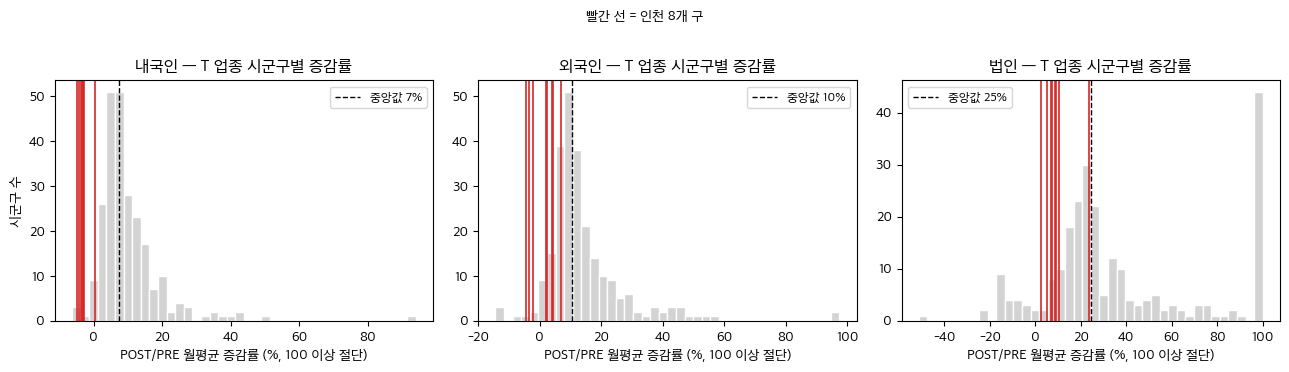

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (k, s) in zip(axes, segs.items()):
    r = region_rate(s[s.grp == 'T']).clip(upper=100)
    others = r[~r.index.str.startswith('인천')]; ic = r[r.index.str.startswith('인천') & ~r.index.str.contains('강화|옹진')]
    ax.hist(others, bins=40, color='lightgrey', edgecolor='white')
    for v in ic: ax.axvline(v, color='C3', lw=1.2)
    ax.axvline(r.median(), color='k', ls='--', lw=1, label=f'중앙값 {r.median():.0f}%')
    ax.set_title(f'{k} — T 업종 시군구별 증감률'); ax.set_xlabel('POST/PRE 월평균 증감률 (%, 100 이상 절단)'); ax.legend(fontsize=9)
axes[0].set_ylabel('시군구 수'); fig.suptitle('빨간 선 = 인천 8개 구', fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

- **내국인**: 인천 8개 구가 하위 1~7% 백분위에 몰린다. 시 단위 충격.
- **외국인**: 인천 8개 구는 하위 2~25%에 흩어진다(계양·동·부평은 마이너스, 연수는 +6.8%). 낮은 편이지만 내국인처럼 뭉치지 않는다.
- **법인**: 하위 11~46%, 분포 안쪽. 중앙값(+24%)보다 낮을 뿐 이례적이지 않다. 회귀 DDD가 법인에서 −10%로 나온 것은 대조군 법인이 전국적으로 급증한 가운데 인천 법인이 그 급증을 덜 탄 것이지, 인천 법인이 내국인처럼 빠진 것은 아니다.

## 5. 요약

| 항목 | 결과 |
|---|---|
| 수동 DSI (전국 / 부산·경남 제외 / 수도권) | **−10.3 / −8.7 / −6.0%p** (이천시 제거 후) |
| 한정식·갈비전문점 제외 | DSI −10.27. 영향 없음 → 포함으로 통일 |
| 회귀 DDD (전국) | β₄ +2.1% (p 0.57), **β₇ −13.1% (p 0.03)** |
| 회귀 DDD (부산·경남 제외 / 수도권) | β₇ −11.5% (p 0.05) / −8.3% (p 0.17) |
| 이벤트 스터디 | 1~3월 +4~+7, 4월 0, **5월 −9.0, 6월 −10.0**. 대형할인점 평탄 |
| 용량반응 — 내국인 | 회귀 β₇ −8.4~−11.1%, 시군구 하위 1~7%. **처치 대상, 감소** |
| 용량반응 — 외국인 | 회귀 β₇ −3.3~−5.2% (p 0.35~0.57), 시군구 하위 2~25%. **용량반응 부합** (내국인의 1/3, 같은 방향) |
| 위약검정 — 법인 (유일한 대상) | 회귀 β₇ −10~−32% (유의). **대조군 이상으로 판정 불가.** 절대 수준 +9.1%, 시군구 백분위 11~46%로 분포 안쪽 |

**세그먼트 결과의 해석 방향 (보고서 반영 필요)**
1. 외국인은 위약검정이 아니라 용량반응 근거다. 가입은 가능하나 이용이 적은 집단에서 효과가 작고 같은 방향이다.
2. 위약검정 대상은 법인 하나였고, 대조군 이상(5~6월 법인 소비 전국 급증, 경남 +593%)으로 판정 불가다. "통과"도 "실패"도 아닌 판정 불가로 쓴다.
3. 법인은 절대 수준(+9%)과 시군구 순위(분포 안쪽)가 내국인(하위 1~7%)과 뚜렷이 달라 "내국인과 같은 시 단위 충격은 없었다"까지만 주장. 법인 급증 원인이 확인되기 전에는 한계 표에 반례로 기재한다.